In [4]:
%pip install -q langgraph

Note: you may need to restart the kernel to use updated packages.


# Intelligent Support Ticket Routing

Task 1: define the shared LangGraph state for the workflow.

In [5]:
from typing import Any, Literal, NotRequired, TypedDict

from langgraph.graph import StateGraph, START, END


In [6]:
TicketCategory = Literal["billing", "technical", "feature_request", "account_management", "other"]
UrgencyLevel = Literal["low", "medium", "high", "urgent"]
RouteDecision = Literal[
    "billing_specialist",
    "technical_support",
    "senior_engineer",
    "product_team",
    "account_specialist",
    "general_support",
]


class TicketState(TypedDict):
    """Shared state passed between LangGraph workflow nodes."""

    ticket_content: str
    category: NotRequired[TicketCategory]
    classification_confidence: NotRequired[float]
    urgency: NotRequired[UrgencyLevel]
    routing_decision: NotRequired[RouteDecision]
    metadata: NotRequired[dict[str, Any]]


## Task 2: Design Workflow Nodes

The workflow has three core nodes: classify the ticket, assess urgency, and choose the final routing destination.

| Node | Input from state | Processing | Adds or updates in state |
| --- | --- | --- | --- |
| `classify_ticket` | `ticket_content` | Checks the ticket text for billing, technical, feature request, and account keywords | `category`, `classification_confidence` |
| `assess_urgency` | `ticket_content` | Checks the ticket text for urgency keywords such as urgent, critical, outage, ASAP, and blocked | `urgency` |
| `route_ticket` | `category`, `urgency` | Chooses the right support team. Urgent or high-priority technical issues go to senior engineers | `routing_decision` |

In [7]:
def classify_ticket(state: TicketState) -> TicketState:
    """Analyze ticket content and determine the support category."""
    content = state["ticket_content"].lower()

    if any(word in content for word in ["invoice", "payment", "billing", "charge", "refund"]):
        category: TicketCategory = "billing"
        confidence = 0.90
    elif any(word in content for word in ["bug", "error", "crash", "broken", "api", "integration"]):
        category = "technical"
        confidence = 0.88
    elif any(word in content for word in ["feature", "request", "enhancement", "improve"]):
        category = "feature_request"
        confidence = 0.82
    elif any(word in content for word in ["account", "login", "password", "profile", "access"]):
        category = "account_management"
        confidence = 0.86
    else:
        category = "other"
        confidence = 0.50

    return {
        **state,
        "category": category,
        "classification_confidence": confidence,
    }


def assess_urgency(state: TicketState) -> TicketState:
    """Evaluate urgency from keywords and ticket context."""
    content = state["ticket_content"].lower()

    if any(word in content for word in ["urgent", "critical", "down", "outage", "blocked"]):
        urgency: UrgencyLevel = "urgent"
    elif any(word in content for word in ["asap", "immediately", "production", "cannot work"]):
        urgency = "high"
    elif any(word in content for word in ["soon", "issue", "problem"]):
        urgency = "medium"
    else:
        urgency = "low"

    return {**state, "urgency": urgency}


def route_ticket(state: TicketState) -> TicketState:
    """Make the final routing decision from category and urgency."""
    category = state.get("category", "other")
    urgency = state.get("urgency", "low")

    if category == "technical" and urgency in ["high", "urgent"]:
        route: RouteDecision = "senior_engineer"
    elif category == "technical":
        route = "technical_support"
    elif category == "billing":
        route = "billing_specialist"
    elif category == "feature_request":
        route = "product_team"
    elif category == "account_management":
        route = "account_specialist"
    else:
        route = "general_support"

    return {**state, "routing_decision": route}


## Task 3: Map Conditional Logic

Conditional flow:

1. Every ticket starts with `classify_ticket`.
2. Every classified ticket goes to `assess_urgency`.
3. Tickets go directly to `route_ticket` when the category is clear and confidence is high enough.
4. Tickets go through `additional_review` first when the classifier is unsure, the category is `other`, or the confidence is below `0.70`.
5. High-urgency technical tickets are routed to `senior_engineer`; normal technical tickets go to `technical_support`.
6. Billing, feature request, and account management tickets are routed to their matching specialist teams.

Simple flowchart:

`START -> classify_ticket -> assess_urgency -> needs review? -> additional_review -> route_ticket -> END`

`START -> classify_ticket -> assess_urgency -> clear ticket? -> route_ticket -> END`


In [8]:
def additional_review(state: TicketState) -> TicketState:
    """Add metadata for tickets that need extra human or AI review before routing."""
    metadata = state.get("metadata", {})

    return {
        **state,
        "metadata": {
            **metadata,
            "needs_additional_review": True,
            "review_reason": "Low confidence or unclear ticket category",
        },
    }


def choose_review_path(state: TicketState) -> Literal["additional_review", "route_ticket"]:
    """Decide whether to route immediately or add an extra review step first."""
    confidence = state.get("classification_confidence", 0)
    category = state.get("category", "other")

    if category == "other" or confidence < 0.70:
        return "additional_review"

    return "route_ticket"


workflow = StateGraph(TicketState)

workflow.add_node("classify_ticket", classify_ticket)
workflow.add_node("assess_urgency", assess_urgency)
workflow.add_node("additional_review", additional_review)
workflow.add_node("route_ticket", route_ticket)

workflow.add_edge(START, "classify_ticket")
workflow.add_edge("classify_ticket", "assess_urgency")
workflow.add_conditional_edges(
    "assess_urgency",
    choose_review_path,
    {
        "additional_review": "additional_review",
        "route_ticket": "route_ticket",
    },
)
workflow.add_edge("additional_review", "route_ticket")
workflow.add_edge("route_ticket", END)

ticket_routing_graph = workflow.compile()


## Invoke and Visualize the Graph

Display the graph structure, then test it with a few support ticket examples.

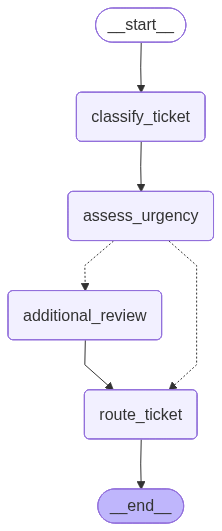

In [9]:
from IPython.display import Image, Markdown, display

try:
    display(Image(ticket_routing_graph.get_graph().draw_mermaid_png()))
except Exception:
    mermaid_diagram = ticket_routing_graph.get_graph().draw_mermaid()
    display(Markdown(f"```mermaid\n{mermaid_diagram}\n```"))


In [10]:
from pprint import pprint

sample_tickets = [
    "I was charged twice on my latest invoice and need a refund.",
    "Urgent: our production API integration is down and users are blocked.",
    "I cannot log in to my account after resetting my password.",
    "Something strange is happening and I need help figuring out the right team.",
]

for ticket in sample_tickets:
    result = ticket_routing_graph.invoke({"ticket_content": ticket})
    print("Ticket:", ticket)
    pprint(result)
    print("-" * 80)


Ticket: I was charged twice on my latest invoice and need a refund.
{'category': 'billing',
 'classification_confidence': 0.9,
 'routing_decision': 'billing_specialist',
 'ticket_content': 'I was charged twice on my latest invoice and need a '
                   'refund.',
 'urgency': 'low'}
--------------------------------------------------------------------------------
Ticket: Urgent: our production API integration is down and users are blocked.
{'category': 'technical',
 'classification_confidence': 0.88,
 'routing_decision': 'senior_engineer',
 'ticket_content': 'Urgent: our production API integration is down and users '
                   'are blocked.',
 'urgency': 'urgent'}
--------------------------------------------------------------------------------
Ticket: I cannot log in to my account after resetting my password.
{'category': 'account_management',
 'classification_confidence': 0.86,
 'routing_decision': 'account_specialist',
 'ticket_content': 'I cannot log in to my accoun

## Completion Criteria

- The state schema stores the original ticket, classification result, urgency, routing decision, and metadata.
- The three core nodes define their expected state input, processing, and state updates.
- The conditional logic sends clear tickets directly to routing and sends unclear or low-confidence tickets through additional review first.
- This improves on a simple linear process because urgent and complex tickets can be prioritized, unclear tickets can be reviewed before routing, and each ticket can be sent to the most appropriate specialist instead of one shared queue.